# 1. Установка библиотеки gmdhpy

In [1]:
!pip install git+https://github.com/kvoyager/GmdhPy.git

  Cloning https://github.com/kvoyager/GmdhPy.git to /tmp/pip-req-build-mzurhojn
  Running command git clone --filter=blob:none --quiet https://github.com/kvoyager/GmdhPy.git /tmp/pip-req-build-mzurhojn
  Resolved https://github.com/kvoyager/GmdhPy.git to commit 26acdbb1e2b5c40a852a2964367468b016caafd9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for GmdhPy: filename=gmdhpy-2.1.1-py3-none-any.whl size=20499 sha256=5cf5847fcfb69386bbc33e62fbe174d04523bdc4c55c018a499dd70a2db28f02
  Stored in directory: /tmp/pip-ephem-wheel-cache-t1p2_ccl/wheels/f4/02/bd/69530335ce3bf82da264be4faf00f837bfea507ac5151b884c
Successfully built GmdhPy


In [2]:
from gmdhpy import gmdh

print("Библиотека gmdhpy успешно импортирована")

Библиотека gmdhpy успешно импортирована


# 2. Импорт библиотек

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor

from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from gmdhpy import gmdh

# 3. Загрузка датасета

In [4]:
data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

df = X.copy()
df["target"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# 4. Первичный анализ данных

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
print("Размер датасета:", df.shape)
print("Количество пропусков:")
print(df.isnull().sum())

Размер датасета: (20640, 9)
Количество пропусков:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64


# 5. Визуализация данных

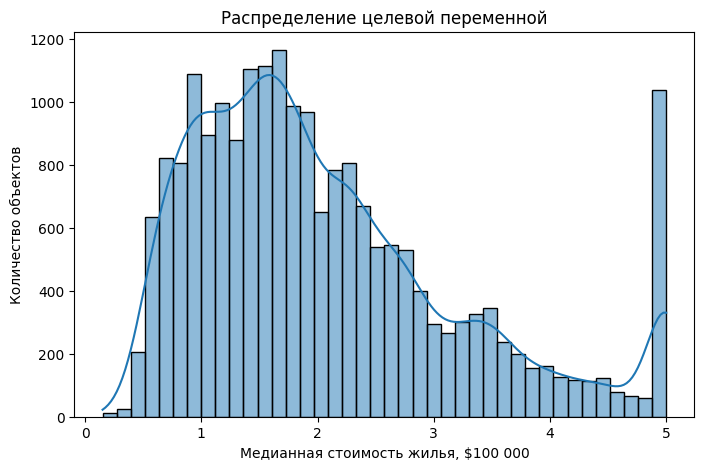

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["target"], bins=40, kde=True)
plt.title("Распределение целевой переменной")
plt.xlabel("Медианная стоимость жилья, $100 000")
plt.ylabel("Количество объектов")
plt.show()

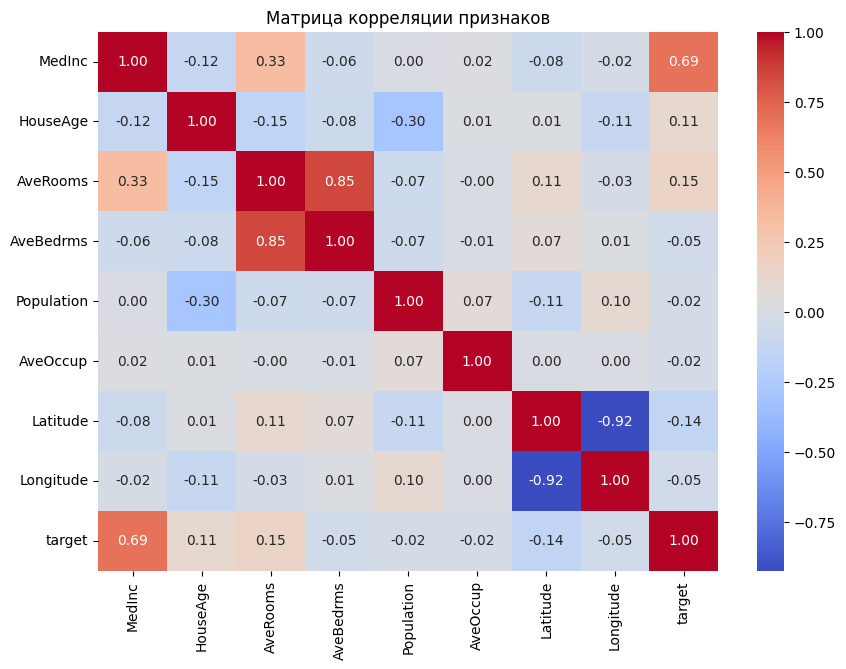

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Матрица корреляции признаков")
plt.show()

# 6. Разделение выборки

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (16512, 8)
Размер тестовой выборки: (4128, 8)


# 7. Функция для оценки качества моделей

In [11]:
def calculate_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Модель": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# 8. Базовые модели для сравнения

In [12]:
results = []

models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "DecisionTreeRegressor": DecisionTreeRegressor(
        random_state=42,
        max_depth=10
    ),

    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=12,
        n_jobs=-1
    ),

    "GradientBoostingRegressor": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append(calculate_metrics(model_name, y_test, y_pred))

pd.DataFrame(results)

,Модель,MAE,MSE,RMSE,R2
0,LinearRegression,0.533200,0.555892,0.745581,0.575788
1,DecisionTreeRegressor,0.433203,0.415468,0.644568,0.682948
2,RandomForestRegressor,0.345891,0.273768,0.523228,0.791082
3,GradientBoostingRegressor,0.382905,0.310104,0.556870,0.763353


# 9. Модель стекинга

In [13]:
estimators = [
    ("lr", Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])),

    ("tree", DecisionTreeRegressor(
        random_state=42,
        max_depth=8
    )),

    ("rf", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=12,
        n_jobs=-1
    )),

    ("gb", GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)

y_pred_stacking = stacking_model.predict(X_test)

results.append(calculate_metrics("StackingRegressor", y_test, y_pred_stacking))

pd.DataFrame(results)

,Модель,MAE,MSE,RMSE,R2
0,LinearRegression,0.533200,0.555892,0.745581,0.575788
1,DecisionTreeRegressor,0.433203,0.415468,0.644568,0.682948
2,RandomForestRegressor,0.345891,0.273768,0.523228,0.791082
3,GradientBoostingRegressor,0.382905,0.310104,0.556870,0.763353
4,StackingRegressor,0.340171,0.266980,0.516701,0.796262


# 10. Многослойный персептрон

In [14]:
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0005,
        learning_rate_init=0.001,
        max_iter=700,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

results.append(calculate_metrics("MLPRegressor", y_test, y_pred_mlp))

pd.DataFrame(results)

,Модель,MAE,MSE,RMSE,R2
0,LinearRegression,0.533200,0.555892,0.745581,0.575788
1,DecisionTreeRegressor,0.433203,0.415468,0.644568,0.682948
2,RandomForestRegressor,0.345891,0.273768,0.523228,0.791082
3,GradientBoostingRegressor,0.382905,0.310104,0.556870,0.763353
4,StackingRegressor,0.340171,0.266980,0.516701,0.796262
5,MLPRegressor,0.356072,0.269334,0.518974,0.794465


# 11. Модели МГУА через gmdhpy

In [15]:
# Подготовка данных для моделей МГУА

X_gmdh_sample = X_train.sample(n=3000, random_state=42)
y_gmdh_sample = y_train.loc[X_gmdh_sample.index]

X_gmdh_train, X_gmdh_valid, y_gmdh_train, y_gmdh_valid = train_test_split(
    X_gmdh_sample,
    y_gmdh_sample,
    test_size=0.2,
    random_state=42
)

scaler_gmdh = StandardScaler()

X_gmdh_train_scaled = scaler_gmdh.fit_transform(X_gmdh_train)
X_gmdh_valid_scaled = scaler_gmdh.transform(X_gmdh_valid)
X_test_scaled_for_gmdh = scaler_gmdh.transform(X_test)

## 11.1. Первая модель МГУА

In [26]:
gmdh_model_1 = gmdh.Regressor()

gmdh_model_1.fit(X_gmdh_train_scaled, y_gmdh_train.values)

y_pred_gmdh_1 = gmdh_model_1.predict(X_test_scaled_for_gmdh)

print("Количество inf в прогнозе GMDH_Regressor:", np.isinf(y_pred_gmdh_1).sum())
print("Количество NaN в прогнозе GMDH_Regressor:", np.isnan(y_pred_gmdh_1).sum())

if np.all(np.isfinite(y_pred_gmdh_1)):
    results.append(calculate_metrics("GMDH_Regressor", y_test, y_pred_gmdh_1))
    print("Модель GMDH_Regressor успешно обучена")
    print(gmdh_model_1)
else:
    print("Модель GMDH_Regressor обучилась, но выдала некорректные предсказания: inf или NaN")

pd.DataFrame(results)

train layer0 in 0.15 sec
train layer1 in 0.55 sec
train layer2 in 0.54 sec
train layer3 in 0.47 sec
train layer4 in 0.45 sec
train layer5 in 0.32 sec
train layer6 in 0.41 sec
train layer7 in 0.42 sec
train layer8 in 0.56 sec
Количество inf в прогнозе GMDH_Regressor: 0
Количество NaN в прогнозе GMDH_Regressor: 0
Модель GMDH_Regressor успешно обучена
Self-organizing deep learning polynomial neural network


,Модель,MAE,MSE,RMSE,R2
0,LinearRegression,0.533200,0.555892,0.745581,0.575788
1,DecisionTreeRegressor,0.433203,0.415468,0.644568,0.682948
2,RandomForestRegressor,0.345891,0.273768,0.523228,0.791082
3,GradientBoostingRegressor,0.382905,0.310104,0.556870,0.763353
4,StackingRegressor,0.340171,0.266980,0.516701,0.796262
5,MLPRegressor,0.356072,0.269334,0.518974,0.794465
6,GMDH_Regressor,0.529593,0.528021,0.726651,0.597056
7,GMDH_Regressor,0.529593,0.528021,0.726651,0.597056


## 11.2. Вторая модель МГУА с заданными опорными функциями

In [18]:


try:
    gmdh_model_2 = gmdh.Regressor(
        ref_functions=("linear_cov", "quadratic", "linear")
    )

    gmdh_model_2.fit(
        X_gmdh_train_scaled,
        y_gmdh_train.values,
        validation_data=(X_gmdh_valid_scaled, y_gmdh_valid.values)
    )

    y_pred_gmdh_2 = gmdh_model_2.predict(X_test_scaled_for_gmdh)

    print("Количество inf в прогнозе:", np.isinf(y_pred_gmdh_2).sum())
    print("Количество NaN в прогнозе:", np.isnan(y_pred_gmdh_2).sum())
    print("Минимальное предсказание:", np.nanmin(y_pred_gmdh_2))
    print("Максимальное предсказание:", np.nanmax(y_pred_gmdh_2))

    if np.all(np.isfinite(y_pred_gmdh_2)):
        results.append(calculate_metrics("GMDH_Regressor_ref_functions", y_test, y_pred_gmdh_2))
        print("Модель GMDH_Regressor_ref_functions успешно обучена")
        print(gmdh_model_2)
    else:
        print("Модель GMDH_Regressor_ref_functions обучилась, но выдала некорректные предсказания: inf или NaN")

except Exception as e:
    print("Ошибка при работе со второй моделью GMDH:")
    print(type(e).__name__)
    print(e)

train layer0 in 0.46 sec
train layer1 in 1.63 sec
train layer2 in 1.06 sec
train layer3 in 0.92 sec
train layer4 in 1.43 sec
train layer5 in 0.90 sec
train layer6 in 0.89 sec
train layer7 in 0.56 sec
train layer8 in 0.54 sec
train layer9 in 0.54 sec
train layer10 in 0.52 sec
train layer11 in 0.54 sec
train layer12 in 0.52 sec
train layer13 in 0.56 sec
train layer14 in 0.52 sec
train layer15 in 0.54 sec
train layer16 in 0.63 sec
train layer17 in 0.75 sec
train layer18 in 0.74 sec
train layer19 in 0.76 sec
train layer20 in 0.79 sec
train layer21 in 0.53 sec
train layer22 in 0.55 sec
train layer23 in 0.52 sec
train layer24 in 0.53 sec
train layer25 in 0.52 sec
train layer26 in 0.53 sec
train layer27 in 0.52 sec
train layer28 in 0.52 sec
train layer29 in 0.51 sec
train layer30 in 0.53 sec
train layer31 in 0.51 sec
train layer32 in 0.53 sec
Количество inf в прогнозе: 2
Количество NaN в прогнозе: 0
Минимальное предсказание: -183332375117.0595
Максимальное предсказание: inf
Модель GMDH_Regres

# 12. Итоговое сравнение моделей

In [19]:
final_results_df = pd.DataFrame(results)
final_results_df = final_results_df.sort_values(by="RMSE")

final_results_df

,Модель,MAE,MSE,RMSE,R2
4,StackingRegressor,0.340171,0.266980,0.516701,0.796262
5,MLPRegressor,0.356072,0.269334,0.518974,0.794465
2,RandomForestRegressor,0.345891,0.273768,0.523228,0.791082
3,GradientBoostingRegressor,0.382905,0.310104,0.556870,0.763353
1,DecisionTreeRegressor,0.433203,0.415468,0.644568,0.682948
6,GMDH_Regressor,0.529593,0.528021,0.726651,0.597056
0,LinearRegression,0.533200,0.555892,0.745581,0.575788


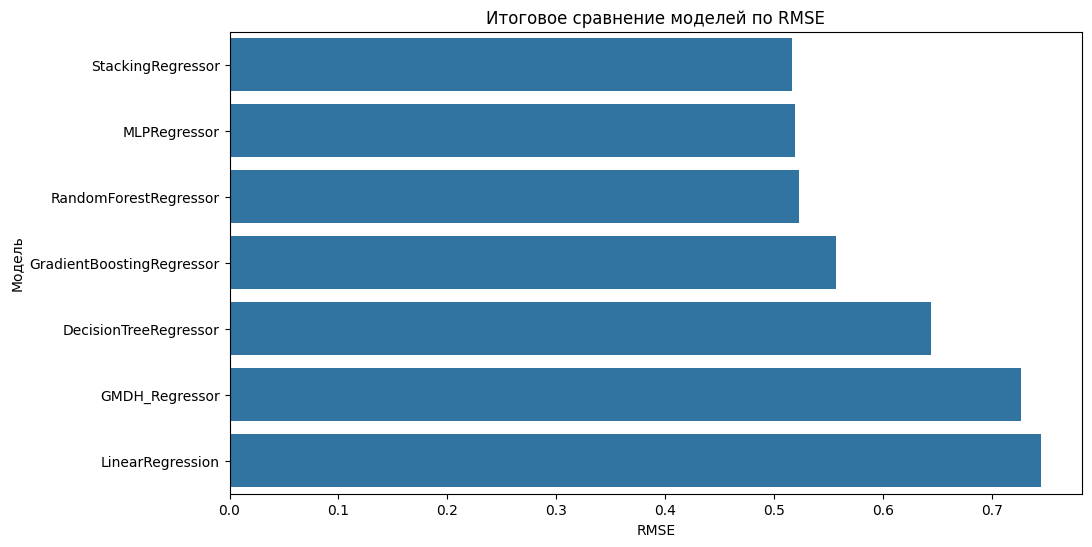

In [20]:
plt.figure(figsize=(11, 6))
sns.barplot(data=final_results_df, x="RMSE", y="Модель")
plt.title("Итоговое сравнение моделей по RMSE")
plt.xlabel("RMSE")
plt.ylabel("Модель")
plt.show()

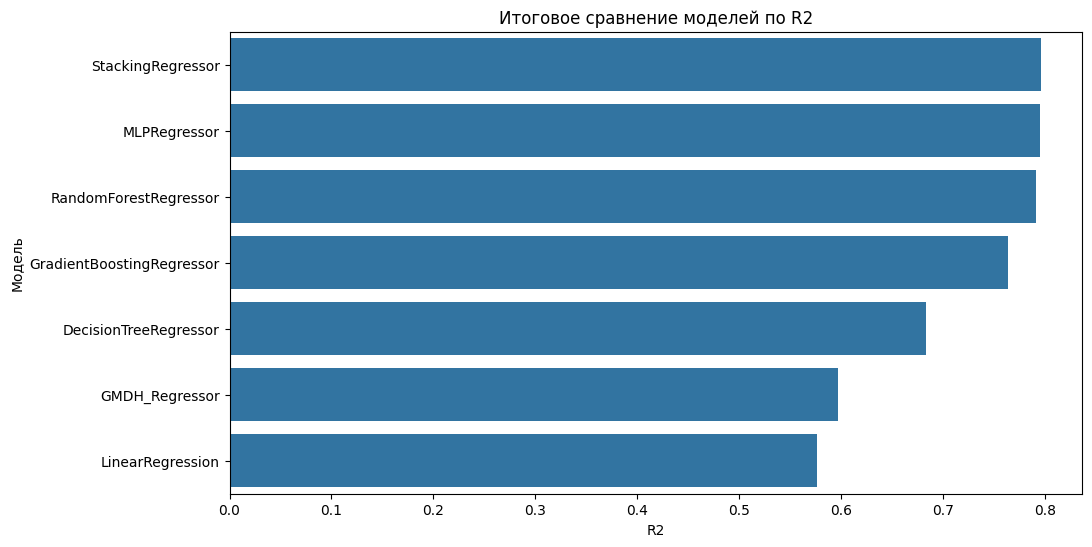

In [21]:
plt.figure(figsize=(11, 6))
sns.barplot(data=final_results_df, x="R2", y="Модель")
plt.title("Итоговое сравнение моделей по R2")
plt.xlabel("R2")
plt.ylabel("Модель")
plt.show()

# 13. Лучшая модель

In [22]:
best_row = final_results_df.iloc[0]

print("Лучшая модель по RMSE:")
print(best_row)

print("\nИнтерпретация:")
print(
    f"Наименьшее значение RMSE показала модель {best_row['Модель']}. "
    f"Значение RMSE составило {best_row['RMSE']:.4f}, "
    f"MAE = {best_row['MAE']:.4f}, "
    f"R2 = {best_row['R2']:.4f}."
)

Лучшая модель по RMSE:
Модель    StackingRegressor
MAE                0.340171
MSE                 0.26698
RMSE               0.516701
R2                 0.796262
Name: 4, dtype: object

Интерпретация:
Наименьшее значение RMSE показала модель StackingRegressor. Значение RMSE составило 0.5167, MAE = 0.3402, R2 = 0.7963.


# 14. График истинных и предсказанных значений для лучшей модели

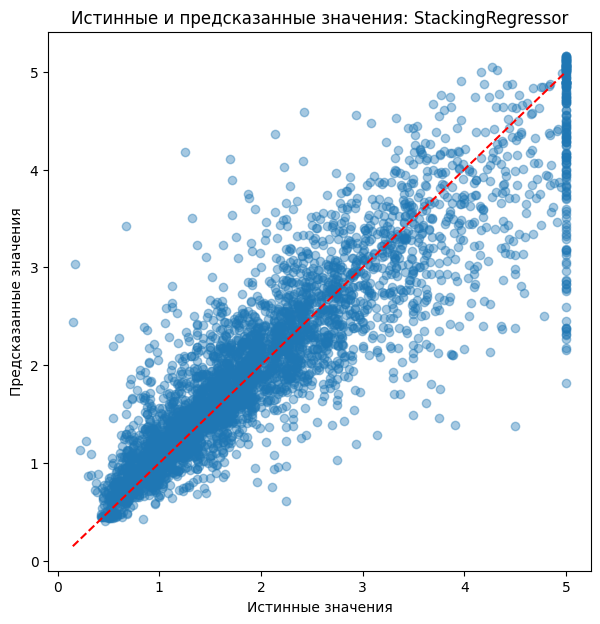

График для GMDH не построен, так как модель не сформировала корректные предсказания.


In [30]:
# 14. График истинных и предсказанных значений для лучшей модели

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_stacking, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Истинные и предсказанные значения: StackingRegressor")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.show()

if "y_pred_gmdh_2" in globals() and np.all(np.isfinite(y_pred_gmdh_2)):
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, y_pred_gmdh_2, alpha=0.4)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    plt.title("Истинные и предсказанные значения: GMDH")
    plt.xlabel("Истинные значения")
    plt.ylabel("Предсказанные значения")
    plt.show()
else:
    print("График для GMDH не построен, так как модель не сформировала корректные предсказания.")

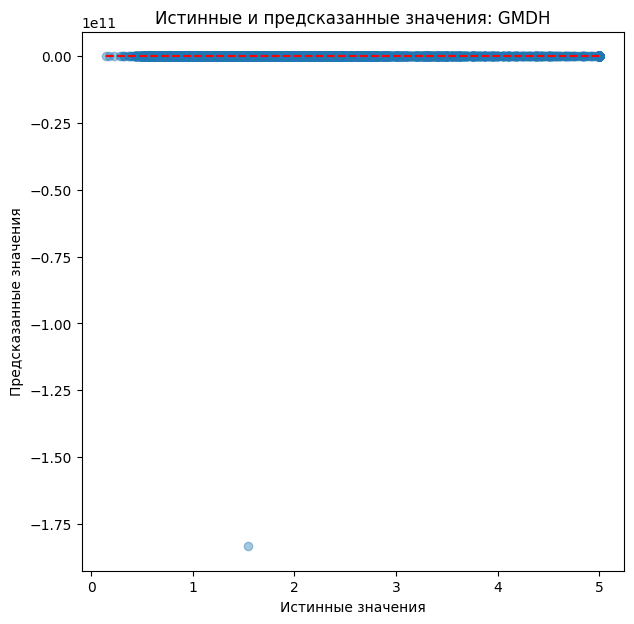

In [24]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_gmdh_2, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Истинные и предсказанные значения: GMDH")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.show()

In [31]:
pd.DataFrame(results)

,Модель,MAE,MSE,RMSE,R2
0,LinearRegression,0.533200,0.555892,0.745581,0.575788
1,DecisionTreeRegressor,0.433203,0.415468,0.644568,0.682948
2,RandomForestRegressor,0.345891,0.273768,0.523228,0.791082
3,GradientBoostingRegressor,0.382905,0.310104,0.556870,0.763353
4,StackingRegressor,0.340171,0.266980,0.516701,0.796262
5,MLPRegressor,0.356072,0.269334,0.518974,0.794465
6,GMDH_Regressor,0.529593,0.528021,0.726651,0.597056
7,GMDH_Regressor,0.529593,0.528021,0.726651,0.597056
